In [5]:
import json
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

In [6]:
def load_jsonl_data(filepath):
    """Reads a JSONL file and converts it into a Pandas DataFrame."""
    data_list = []
    print(f"Loading data from {filepath}...")
    
    try:
        with open(filepath, 'r') as file:
            for line in file:
                record = json.loads(line.strip())
                data_list.append(record)
                
        df = pd.DataFrame(data_list)
        print(f"Successfully loaded {len(df)} records.")
        return df
        
    except FileNotFoundError:
        print(f"Error: Could not find the file '{filepath}'.")
        return None
    except json.JSONDecodeError:
        print("Error: The file contains invalid JSON data.")
        return None

def plot_waveform_and_fft(df, sampling_rate):
    """Plots the waveform and FFT for the first captured sample of X, Y, and Z axes."""
    # Create a 3x2 grid of plots (Rows: X, Y, Z | Cols: Waveform, FFT)
    fig, axs = plt.subplots(3, 2, figsize=(15, 10))
    fig.suptitle('Saved Vibration Data: Waveform & Frequency Spectrum', fontsize=16)
    
    axes_list = ['X', 'Y', 'Z']
    
    for i, axis in enumerate(axes_list):
        ax_wave = axs[i, 0]
        ax_fft = axs[i, 1]
        
        # Filter for this specific axis
        axis_data = df[df['axis'] == axis]
        
        if not axis_data.empty:
            # Grab the raw array from the VERY FIRST row
            raw_waveform = np.array(axis_data.iloc[0]['data'])
            n_samples = len(raw_waveform)
            
            # --- 1. Process Waveform (Time Domain) ---
            time_axis = np.linspace(0, n_samples / sampling_rate, n_samples)
            wave_no_dc = raw_waveform - np.mean(raw_waveform) # Remove DC offset
            
            ax_wave.plot(time_axis, wave_no_dc, color='teal')
            ax_wave.set_title(f'Axis {axis} - Waveform (DC Removed)')
            ax_wave.set_ylabel('Amplitude')
            ax_wave.grid(True, linestyle='--', alpha=0.7)
            
            if i == 2: # Only put x-label on the bottom row
                ax_wave.set_xlabel('Time (s)')

            # --- 2. Process FFT (Frequency Domain) ---
            yf = np.fft.rfft(wave_no_dc)
            fft_mag = np.abs(yf)
            freq_axis = np.fft.rfftfreq(n_samples, 1.0 / sampling_rate)
            
            ax_fft.plot(freq_axis, fft_mag, color='darkorange')
            ax_fft.set_title(f'Axis {axis} - FFT Spectrum')
            ax_fft.set_ylabel('Magnitude')
            ax_fft.grid(True, linestyle='--', alpha=0.7)
            
            if i == 2:
                ax_fft.set_xlabel('Frequency (Hz)')
                
        else:
            ax_wave.set_title(f'{axis}-Axis (No Data Found)')
            ax_fft.set_title(f'{axis}-Axis (No Data Found)')
            
    plt.tight_layout(rect=[0, 0.03, 1, 0.95])
    
    plt.show()

In [8]:
# --- Configuration ---
# Change this to the exact name of your saved file
FILE_PATH = r'E:\UB\Spring 26\CDA-500\Main Project\MMS_Scripts\MMS_Scripts\7CDB3D54_20260305_155317.jsonl' 
SAMPLING_RATE = 50000  # 50 kHz from your original setup

In [9]:
sensor_df = load_jsonl_data(FILE_PATH)

Loading data from E:\UB\Spring 26\CDA-500\Main Project\MMS_Scripts\MMS_Scripts\7CDB3D54_20260305_155317.jsonl...
Successfully loaded 881 records.


In [10]:
sensor_df.head()

,time,axis,data
0,1.772744e+09,X,"[204.1962890625, 144.1962890625, 22.1962890625..."
1,1.772744e+09,Y,"[689.19921875, 550.19921875, 502.19921875, 364..."
2,1.772744e+09,Z,"[362.2919921875, 420.2919921875, 167.291992187..."
3,1.772744e+09,X,"[-91.9638671875, -199.9638671875, -355.9638671..."
4,1.772744e+09,Y,"[-320.72265625, -270.72265625, -248.72265625, ..."


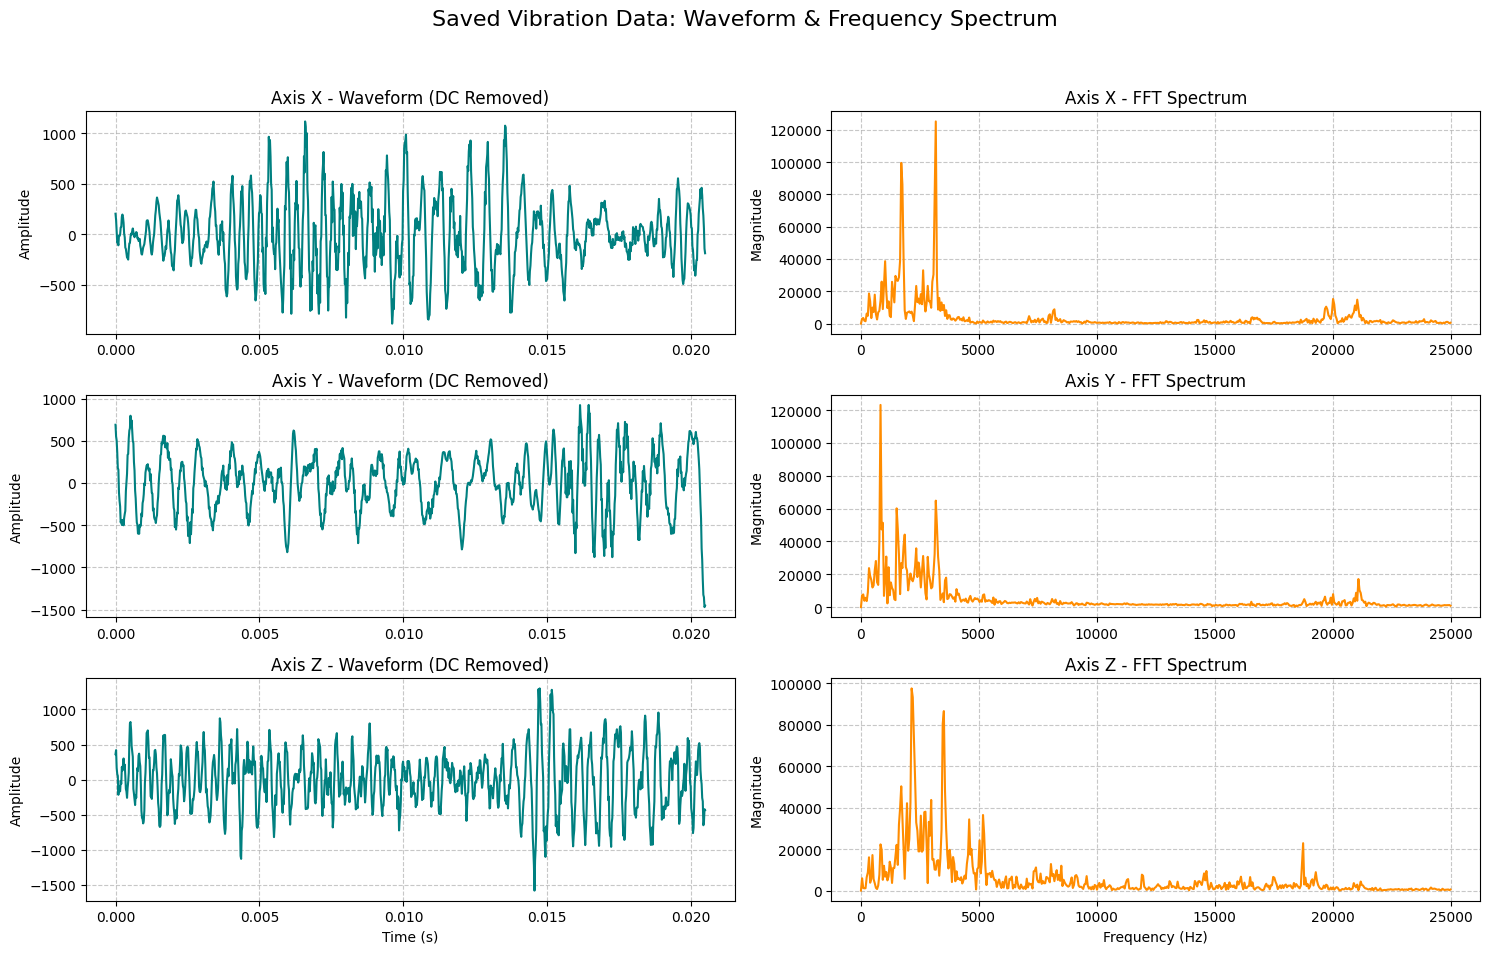

In [11]:
if sensor_df is not None:
    plot_waveform_and_fft(sensor_df, SAMPLING_RATE)